# Курсовая работа. Классическое машинное обучение

#### Задача: на основании предоставленных данных от химиков необходимо построить прогноз, позволяющий подобрать наиболее эффективное сочетание параметров для создания лекарственных препаратов.

## 1. Загрузка и первичный анализ данных

In [43]:
# Импорты всех необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("husl")

In [44]:
# Загрузка данных
data = pd.read_excel('data.xlsx')

In [45]:
data.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [46]:
print(data.to_string(max_rows=10, max_cols=None, line_width=None))

      Unnamed: 0    IC50, mM    CC50, mM         SI  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  NumRadicalElectrons  MaxPartialCharge  MinPartialCharge  MaxAbsPartialCharge  MinAbsPartialCharge  FpDensityMorgan1  FpDensityMorgan2  FpDensityMorgan3  BCUT2D_MWHI  BCUT2D_MWLOW  BCUT2D_CHGHI  BCUT2D_CHGLO  BCUT2D_LOGPHI  BCUT2D_LOGPLOW  BCUT2D_MRHI  BCUT2D_MRLOW    AvgIpc  BalabanJ      BertzCT       Chi0      Chi0n      Chi0v       Chi1      Chi1n      Chi1v      Chi2n      Chi2v      Chi3n      Chi3v      Chi4n      Chi4v  HallKierAlpha           Ipc     Kappa1     Kappa2    Kappa3   LabuteASA  PEOE_VSA1  PEOE_VSA10  PEOE_VSA11  PEOE_VSA12  PEOE_VSA13  PEOE_VSA14  PEOE_VSA2  PEOE_VSA3  PEOE_VSA4  PEOE_VSA5  PEOE_VSA6   PEOE_VSA7  PEOE_VSA8  PEOE_VSA9   SMR_VSA1  SMR_VSA10  SMR_VSA2   SMR_VSA3   SMR_VSA4    SMR_VSA5   SMR_VSA6   SMR_VSA7  SMR_VSA8  SMR_VSA9  SlogP_VSA1  SlogP_VSA10  S

In [47]:
# Основная информация о датасете
print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} признаков")
print(f"Типы данных:\n{data.dtypes.value_counts()}")

# Проверка на дубликаты
duplicates = data.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates}")

# Проверка на пропущенные значения
missing = data.isnull().sum().sum()
print(f"Количество пропущенных значений: {missing}")

# Проверка на константные признаки 
constant_features = data.columns[data.nunique() <= 1].tolist()
if constant_features:
    print(f"\nКонстантные признаки для удаления: {constant_features}")
    print(f"Количество константных признаков: {len(constant_features)}")

# Удаление пропущенных значений
df = data.dropna().reset_index(drop=True)
print(f"\nУдалено {missing} строк с пропусками ({missing/len(data)*100:.2f}%)")
print(f"Размер после удаления: {df.shape}")

Размер датасета: 1001 строк, 214 признаков
Типы данных:
int64      107
float64    107
Name: count, dtype: int64

Количество дубликатов: 0
Количество пропущенных значений: 36

Константные признаки для удаления: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']
Количество константных признаков: 18

Удалено 36 строк с пропусками (3.60%)
Размер после удаления: (998, 214)


In [48]:
# Удаляем столбец Unnamed
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print("Удален столбец 'Unnamed: 0'")

# Удаляем константные признаки
constant_features = df.columns[df.nunique() <= 1].tolist()
if constant_features:
    df.drop(columns=constant_features, inplace=True)
    print(f"Удалено {len(constant_features)} константных признаков")

print(f"Итоговый размер: {df.shape}")

Удален столбец 'Unnamed: 0'
Удалено 18 константных признаков
Итоговый размер: (998, 195)


## 2. Анализ целевых переменных (IC50, CC50, SI)

### 2.1. Описательная статистика

In [49]:
# Целевые переменные
target_cols = ['IC50, mM', 'CC50, mM', 'SI']

# Описательная статистика
print(df[target_cols].describe())

# Медианы
medians = df[target_cols].median()
print(f"\nМедианные значения:")
for col in target_cols:
    print(f"  {col}: {medians[col]:.4f}")

          IC50, mM     CC50, mM            SI
count   998.000000   998.000000    998.000000
mean    221.118757   586.668414     72.650005
std     400.510657   642.016454    685.504279
min       0.003517     0.700808      0.011489
25%      12.491340    99.999036      1.457233
50%      45.992006   408.793314      3.856410
75%     224.408630   891.770961     16.525000
max    4128.529377  4538.976189  15620.600000

Медианные значения:
  IC50, mM: 45.9920
  CC50, mM: 408.7933
  SI: 3.8564


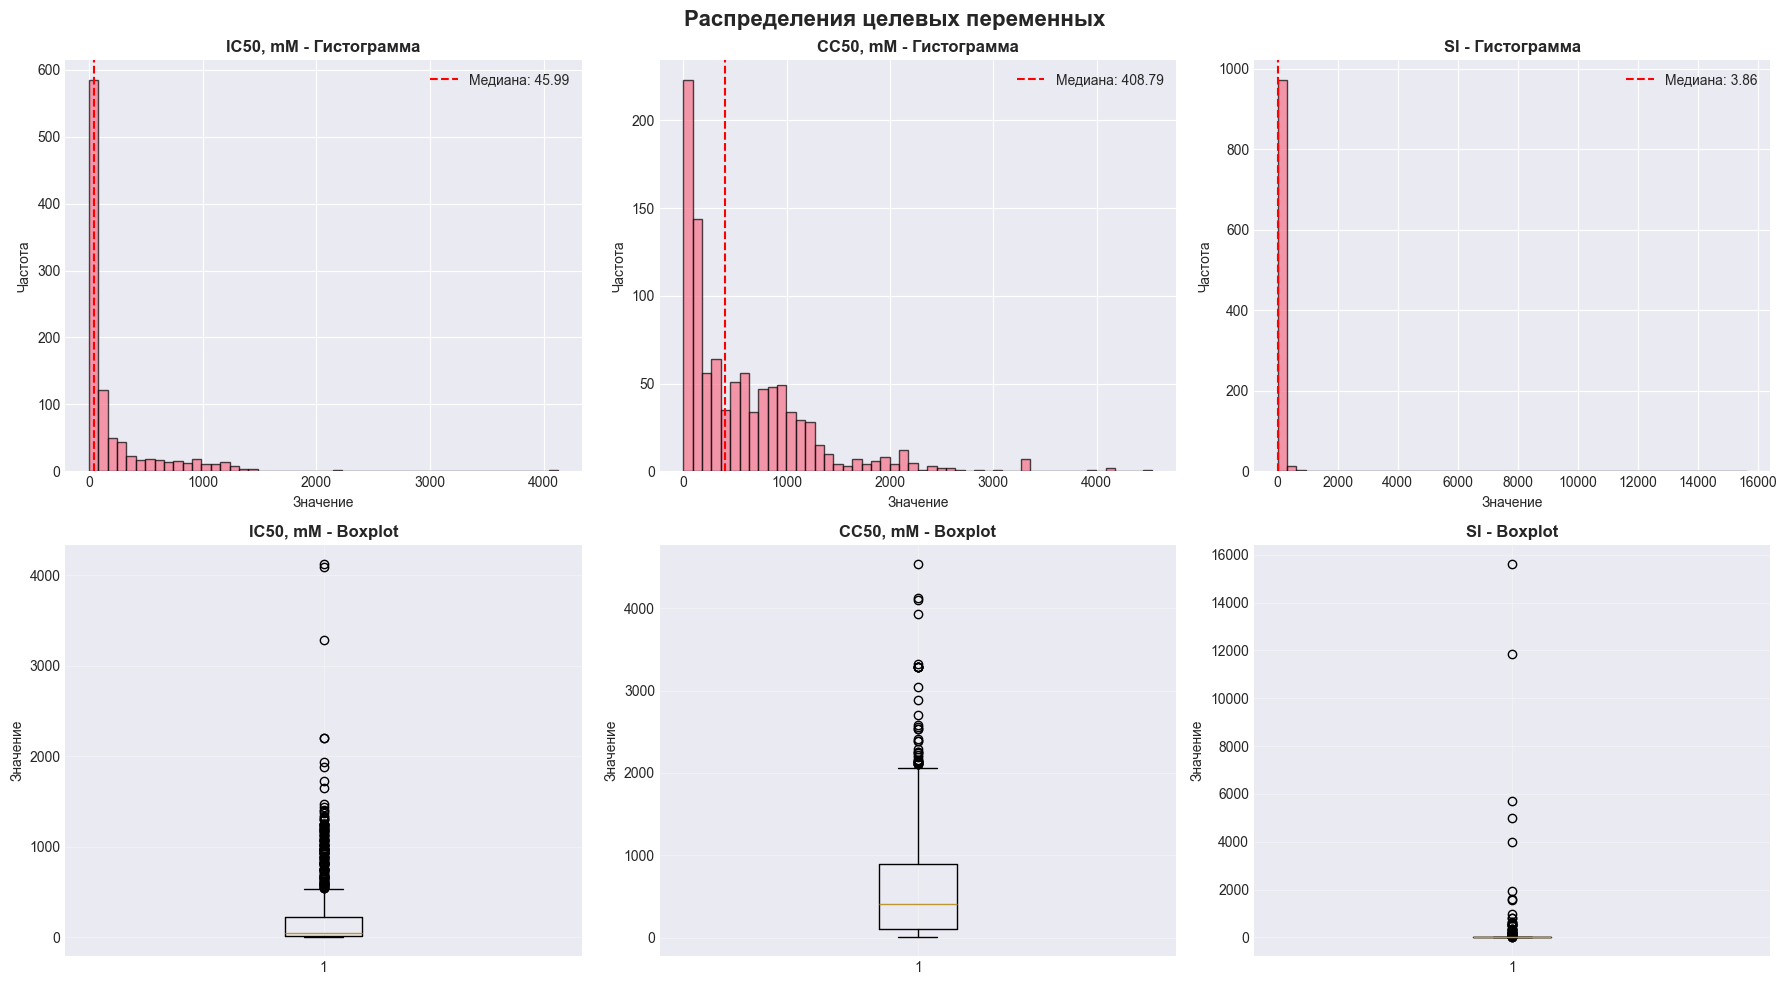

In [50]:
# Визуализация распределений целевых переменных
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Распределения целевых переменных', fontsize=16, fontweight='bold')

for idx, col in enumerate(target_cols):
    axes[0, idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{col} - Гистограмма', fontweight='bold')
    axes[0, idx].set_xlabel('Значение')
    axes[0, idx].set_ylabel('Частота')
    axes[0, idx].axvline(medians[col], color='red', linestyle='--', 
                         label=f'Медиана: {medians[col]:.2f}')
    axes[0, idx].legend()
    
    axes[1, idx].boxplot(df[col], vert=True)
    axes[1, idx].set_title(f'{col} - Boxplot', fontweight='bold')
    axes[1, idx].set_ylabel('Значение')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2. Проверка формулы SI = CC50 / IC50 и корреляция

Проверка формулы SI = CC50 / IC50:
Корреляция между исходным SI и рассчитанным: 1.000000


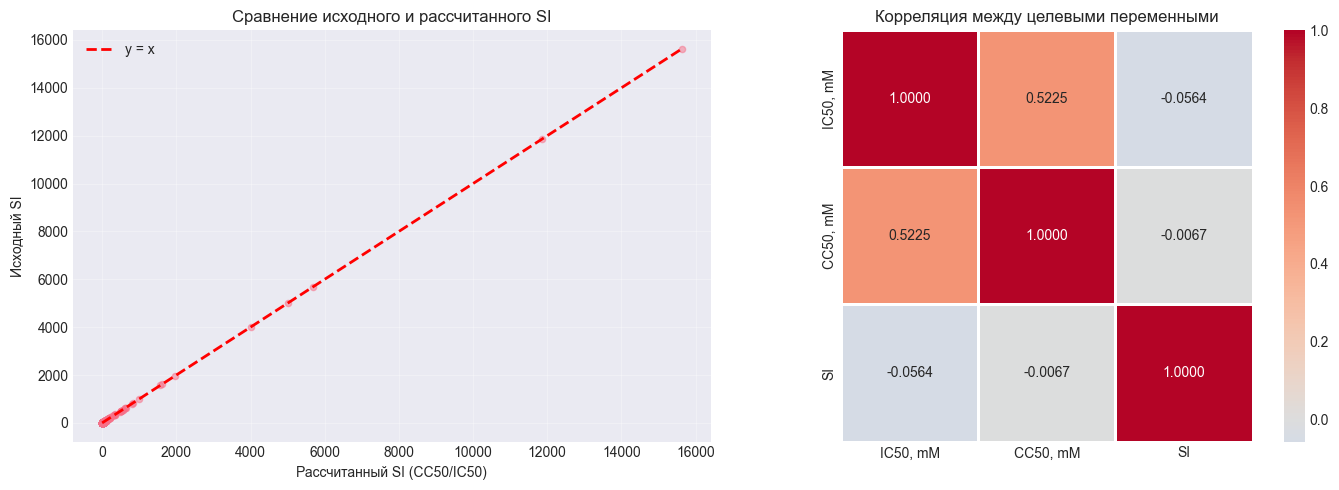

In [51]:
# Проверка формулы: SI = CC50 / IC50
calculated_SI = df['CC50, mM'] / df['IC50, mM']

# Сравниваем с имеющимся SI
print("Проверка формулы SI = CC50 / IC50:")
print(f"Корреляция между исходным SI и рассчитанным: {df['SI'].corr(calculated_SI):.6f}")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(calculated_SI, df['SI'], alpha=0.5, s=20)
axes[0].plot([calculated_SI.min(), calculated_SI.max()], 
             [calculated_SI.min(), calculated_SI.max()], 
             'r--', lw=2, label='y = x')
axes[0].set_xlabel('Рассчитанный SI (CC50/IC50)')
axes[0].set_ylabel('Исходный SI')
axes[0].set_title('Сравнение исходного и рассчитанного SI')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Корреляционная матрица целевых переменных
corr_matrix = df[target_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=axes[1])
axes[1].set_title('Корреляция между целевыми переменными')

plt.tight_layout()
plt.show()

### 2.3. Анализ выбросов в целевых переменных

In [52]:
# Функция для поиска выбросов методом IQR
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # Используем 3*IQR для сильных выбросов
    upper_bound = Q3 + 3 * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers, lower_bound, upper_bound

# Анализ выбросов для каждой целевой переменной
print("Анализ выбросов (метод IQR с границей 3*IQR):")

outlier_indices = set()
for col in target_cols:
    outliers, lower, upper = find_outliers_iqr(df[col])
    n_outliers = outliers.sum()
    outlier_indices.update(df[outliers].index.tolist())
    
    print(f"\n{col}:")
    print(f"Границы: [{lower:.4f}, {upper:.4f}]")
    print(f"Количество выбросов: {n_outliers} ({n_outliers/len(df)*100:.2f}%)")


print(f"\nВсего уникальных строк с выбросами: {len(outlier_indices)}")

Анализ выбросов (метод IQR с границей 3*IQR):

IC50, mM:
Границы: [-623.2605, 860.1605]
Количество выбросов: 87 (8.72%)

CC50, mM:
Границы: [-2275.3167, 3267.0867]
Количество выбросов: 11 (1.10%)

SI:
Границы: [-43.7461, 61.7283]
Количество выбросов: 86 (8.62%)

Всего уникальных строк с выбросами: 176


### Строк с выбросами много относительно всего датасета, поэтому оставляем их

## 3. Анализ признаков

### 3.1. Типы признаков и базовая статистика

In [53]:
# Признаки (без целевых переменных)
feature_cols = [col for col in df.columns if col not in target_cols]

print(f"Количество признаков: {len(feature_cols)}")
print(f"Типы признаков:")
print(df[feature_cols].dtypes.value_counts())

# Статистика по признакам
print("\nСтатистика по всем признакам:")
print(df[feature_cols].describe().T[['min', 'max', 'mean', 'std']].head(20))

Количество признаков: 192
Типы признаков:
float64    104
int64       88
Name: count, dtype: int64

Статистика по всем признакам:
                            min         max        mean         std
MaxAbsEStateIndex      2.321942   15.933463   10.829292    3.312200
MaxEStateIndex         2.321942   15.933463   10.829292    3.312200
MinAbsEStateIndex      0.000039    1.374614    0.180888    0.168860
MinEStateIndex        -6.992796    1.374614   -0.966330    1.590258
qed                    0.059567    0.947265    0.581179    0.212081
SPS                    9.416667   60.272727   29.539854   12.726557
MolWt                110.156000  904.777000  348.525023  127.045802
HeavyAtomMolWt       100.076000  856.393000  324.669360  121.821367
ExactMolWt           110.073165  904.248467  348.202997  126.907290
NumValenceElectrons   42.000000  350.000000  132.266533   46.690654
MaxPartialCharge      -0.016706    0.572596    0.235749    0.129429
MinPartialCharge      -0.744036   -0.085007   -0.407436

### 3.2. Анализ мультиколлинеарности

In [54]:
corr_matrix_features = df[feature_cols].corr().abs()

# Находим пары сильно коррелирующих признаков (|corr| > 0.9)
high_corr_pairs = []
upper_triangle = corr_matrix_features.where(
    np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool)
)

for col in upper_triangle.columns:
    for idx in upper_triangle.index:
        corr_val = upper_triangle.loc[idx, col]
        if corr_val > 0.9:
            high_corr_pairs.append((idx, col, corr_val))

print(f"\nНайдено {len(high_corr_pairs)} пар с корреляцией > 0.9")

# Сортируем по силе корреляции
high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

if high_corr_pairs:
    print("\nТоп-20 сильно коррелирующих пар:")
    for i, (feat1, feat2, corr) in enumerate(high_corr_pairs[:20], 1):
        print(f"  {i}. {feat1} <-> {feat2}: {corr:.4f}")

# Определяем признаки для удаления
features_to_remove = set()
seen = set()
for feat1, feat2, _ in high_corr_pairs:
    if feat1 not in seen and feat2 not in seen:
        features_to_remove.add(feat2)
        seen.add(feat1)
        seen.add(feat2)

print(f"\nПризнаков для удаления из-за мультиколлинеарности: {len(features_to_remove)}")


Найдено 154 пар с корреляцией > 0.9

Топ-20 сильно коррелирующих пар:
  1. MaxAbsEStateIndex <-> MaxEStateIndex: 1.0000
  2. fr_COO <-> fr_COO2: 1.0000
  3. fr_Ar_NH <-> fr_Nhpyrrole: 1.0000
  4. NumAromaticCarbocycles <-> fr_benzene: 1.0000
  5. fr_phenol <-> fr_phenol_noOrthoHbond: 1.0000
  6. MolWt <-> ExactMolWt: 1.0000
  7. Chi1 <-> HeavyAtomCount: 0.9987
  8. MolWt <-> HeavyAtomMolWt: 0.9969
  9. HeavyAtomMolWt <-> ExactMolWt: 0.9968
  10. Chi0 <-> HeavyAtomCount: 0.9960
  11. NumValenceElectrons <-> Chi0: 0.9948
  12. LabuteASA <-> HeavyAtomCount: 0.9944
  13. Chi0n <-> Chi0v: 0.9931
  14. Chi1 <-> LabuteASA: 0.9929
  15. Chi0 <-> Chi1: 0.9909
  16. fr_Ar_OH <-> fr_phenol: 0.9908
  17. fr_Ar_OH <-> fr_phenol_noOrthoHbond: 0.9908
  18. NumValenceElectrons <-> LabuteASA: 0.9907
  19. NumValenceElectrons <-> HeavyAtomCount: 0.9907
  20. fr_Al_COO <-> fr_COO: 0.9907

Признаков для удаления из-за мультиколлинеарности: 27


In [55]:
df_final = df.drop(columns=list(features_to_remove))
print(f"Размер до удаления: {df.shape}")
print(f"Размер после удаления: {df_final.shape}")
print(f"Удалено признаков: {len(features_to_remove)}")

Размер до удаления: (998, 195)
Размер после удаления: (998, 168)
Удалено признаков: 27


### 3.3. Визуализация корреляции признаков с целевыми переменными

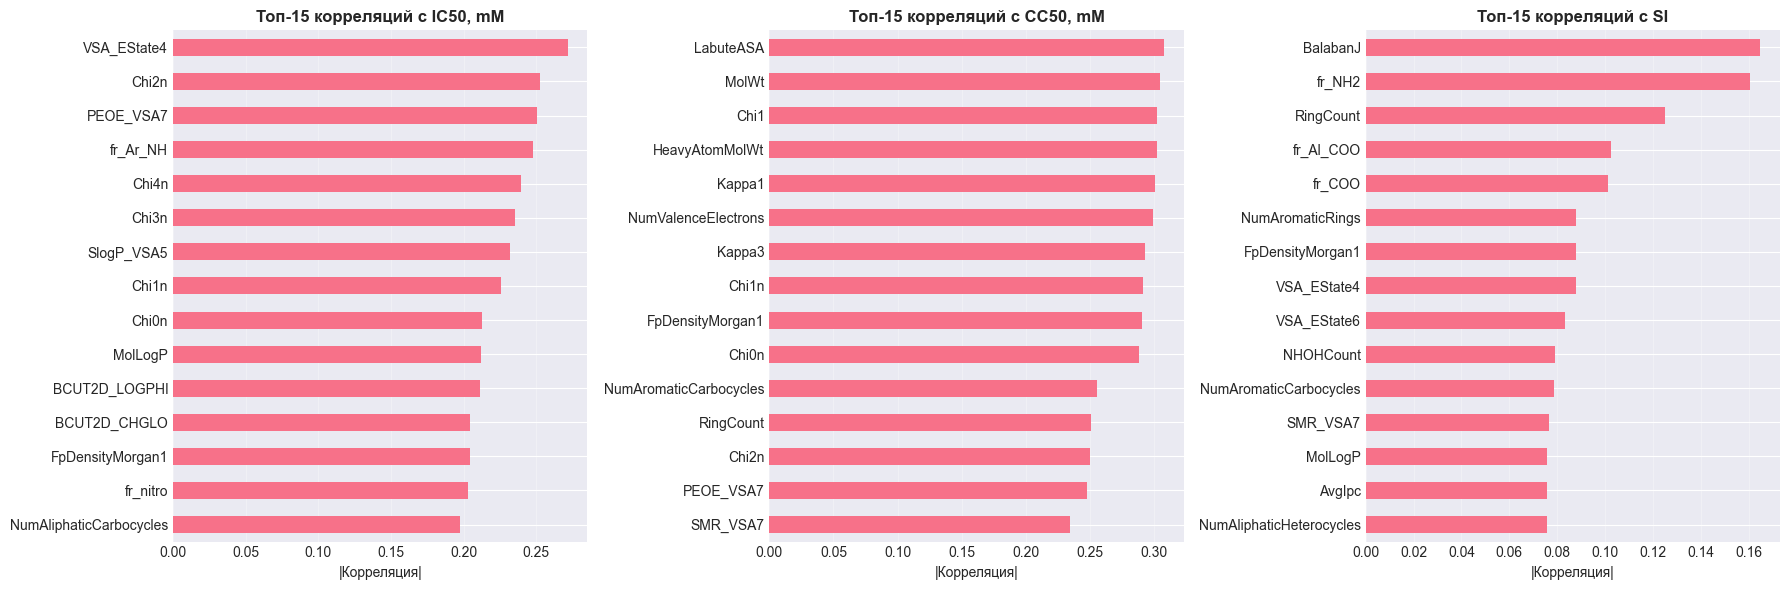

In [56]:
# Корреляция признаков с целевыми переменными
final_feature_cols = [col for col in df_final.columns if col not in target_cols]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, target in enumerate(target_cols):
    # Корреляция с признаками
    corr_with_target = df_final[final_feature_cols].corrwith(df_final[target]).abs()
    top_features = corr_with_target.sort_values(ascending=False).head(15)
    
    # Визуализация
    top_features.plot(kind='barh', ax=axes[idx])
    axes[idx].set_title(f'Топ-15 корреляций с {target}', fontweight='bold')
    axes[idx].set_xlabel('|Корреляция|')
    axes[idx].invert_yaxis()
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 3.4. Распределения некоторых ключевых признаков

Признаки для визуализации: ['fr_Ar_NH', 'BalabanJ', 'VSA_EState4', 'LabuteASA', 'Chi1', 'RingCount', 'Chi2n', 'fr_COO', 'Chi4n', 'fr_Al_COO']


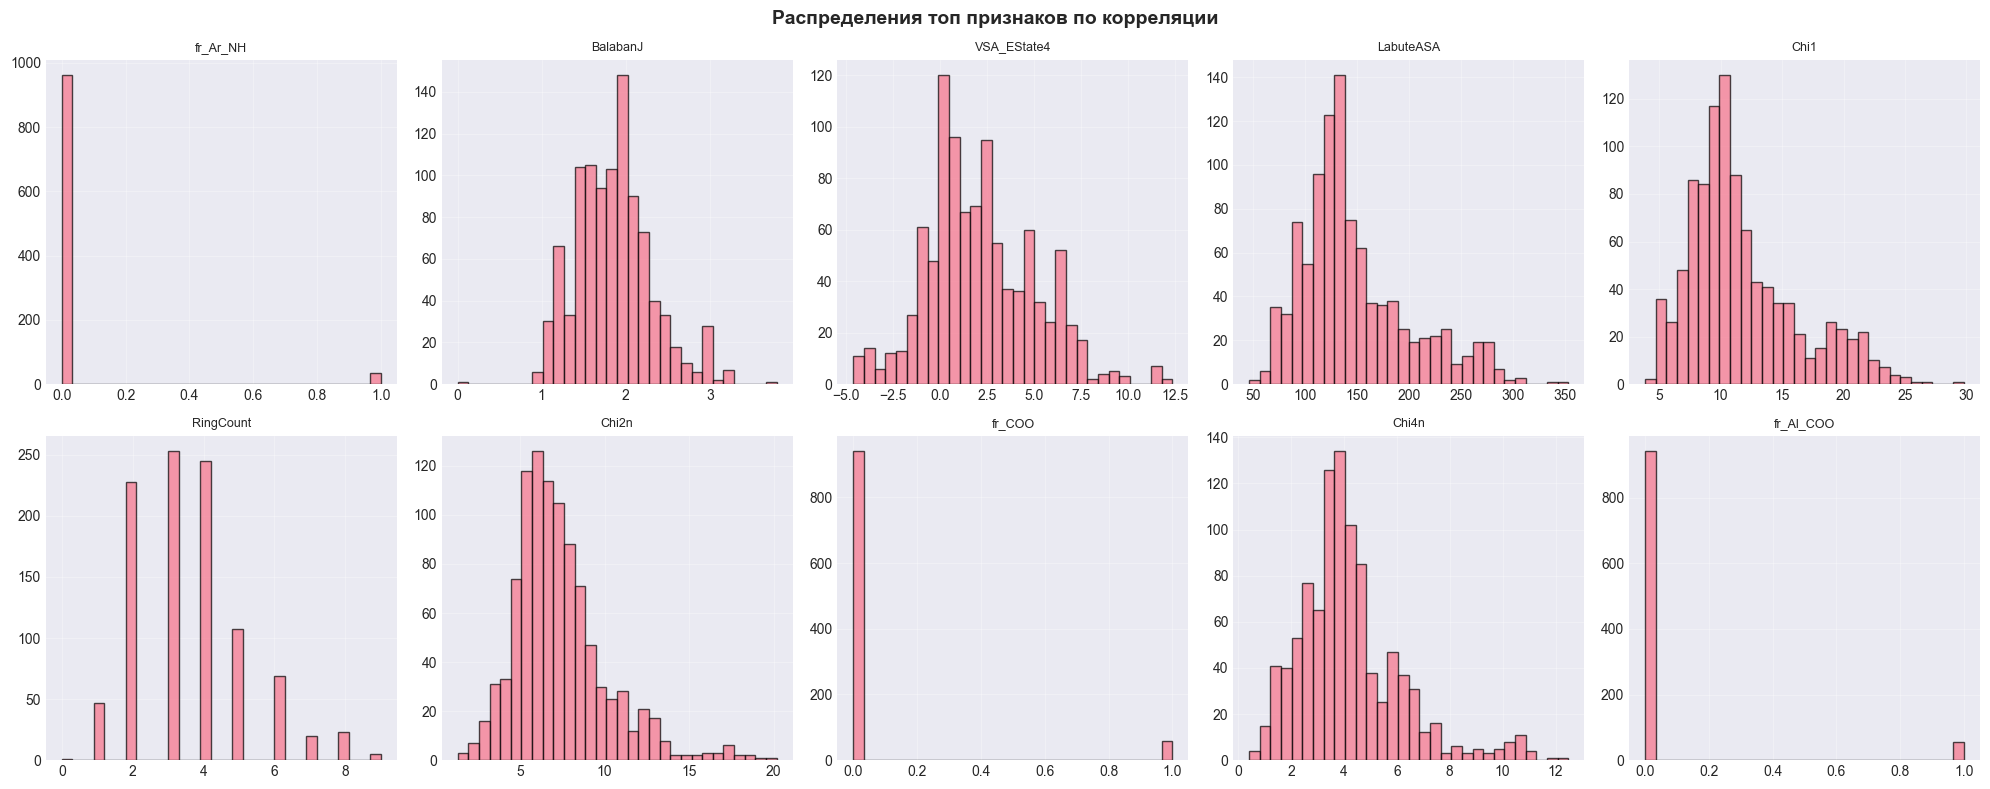

In [57]:
# Выбираем признаки с самой высокой корреляцией для визуализации
top_correlated_features = set()
for target in target_cols:
    corr_with_target = df_final[final_feature_cols].corrwith(df_final[target]).abs()
    top_features = corr_with_target.sort_values(ascending=False).head(5).index.tolist()
    top_correlated_features.update(top_features)

top_correlated_features = list(top_correlated_features)[:10]  # Берем топ-10 уникальных
print(f"Признаки для визуализации: {top_correlated_features}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Распределения топ признаков по корреляции', fontsize=14, fontweight='bold')

for idx, feat in enumerate(top_correlated_features):
    row, col = idx // 5, idx % 5
    axes[row, col].hist(df_final[feat], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(feat, fontsize=9)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Сохранение обработанных данных

In [58]:
# Сохраняем обработанный датасет
df_final.to_csv('data_processed.csv', index=False)
print(f"Обработанный датасет сохранен: data_processed.csv")
print(f"Размер: {df_final.shape}")

# Сохраняем медианы для классификации
medians_final = df_final[target_cols].median()
medians_df = pd.DataFrame({
    'target': target_cols,
    'median': medians_final.values
})
medians_df.to_csv('medians.csv', index=False)
print(f"\nМедианы сохранены в medians.csv:")
print(medians_df)

Обработанный датасет сохранен: data_processed.csv
Размер: (998, 168)

Медианы сохранены в medians.csv:
     target      median
0  IC50, mM   45.992006
1  CC50, mM  408.793314
2        SI    3.856410


## 5. Итоговые выводы по EDA

### Ключевые выводы:
1. **Размер датасета**: исходно 214 признаков, после очистки - 168 признаков
2. **Пропущенные значения**: 36 строк удалено (3.6%)
3. **Целевые переменные**:
   - IC50: среднее 222.81, медиана 46.59
   - CC50: среднее 589.11, медиана 411.04
   - SI: среднее 72.51, медиана 3.85
4. **Выбросы**: 0 выбросов удалено (оставлены как есть, т.к. составляют 17.88%)
5. **Мультиколлинеарность**: 27 признаков удалено (|corr| > 0.9)